# Superstore Sales Data Analysis

## Objective
The objective of this project is to analyze sales, profit, and discount patterns across different regions, products, and customer segments to derive actionable business insights.

## Dataset
The dataset contains 51,000+ records of sales transactions including product, region, customer, and financial metrics.

In [1]:
import pandas as pd

df = pd.read_csv("superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


## Data Cleaning

In [2]:
df.columns


Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

In [4]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [5]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  str           
 1   City            51290 non-null  str           
 2   Country         51290 non-null  str           
 3   Customer.ID     51290 non-null  str           
 4   Customer.Name   51290 non-null  str           
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  str           
 7   记录数             51290 non-null  int64         
 8   Order.Date      51290 non-null  datetime64[us]
 9   Order.ID        51290 non-null  str           
 10  Order.Priority  51290 non-null  str           
 11  Product.ID      51290 non-null  str           
 12  Product.Name    51290 non-null  str           
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Region       

In [7]:
df = df.drop(columns=['记录数'])

## Exploratory Data Analysis

In [8]:
df[ 'Sales' ].sum()

np.int64(12642905)

In [9]:
df['Profit'].sum()

np.float64(1467457.2912800002)

In [10]:
df.groupby('Region')['Sales'].sum()

Region
Africa             783776
Canada              66932
Caribbean          324281
Central           2822399
Central Asia       752839
EMEA               806184
East               678834
North             1248192
North Asia         848349
Oceania           1100207
South             1600960
Southeast Asia     884438
West               725514
Name: Sales, dtype: int64

In [11]:
df.groupby('Category')['Profit'].sum()

Category
Furniture          285204.72380
Office Supplies    518473.83430
Technology         663778.73318
Name: Profit, dtype: float64

In [12]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: Profit, dtype: float64

In [13]:
df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head()

Country
United States    2297354
Australia         925257
France            858930
China             700591
Germany           628857
Name: Sales, dtype: int64

In [14]:
df.groupby('Product.Name')['Profit'].sum().sort_values(ascending=False).head()

Product.Name
Canon imageCLASS 2200 Advanced Copier    25199.9280
Cisco Smart Phone, Full Size             17238.5206
Motorola Smart Phone, Full Size          17027.1130
Hoover Stove, Red                        11807.9690
Sauder Classic Bookcase, Traditional     10672.0730
Name: Profit, dtype: float64

In [15]:
df.groupby('Discount')['Profit'].mean()

Discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      63.683426
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: Profit, dtype: float64

In [16]:
df.groupby('Country')['Profit'].sum().sort_values(ascending=False).head()

Country
United States     286397.0217
China             150683.0850
India             129071.8350
United Kingdom    111900.1500
France            109029.0030
Name: Profit, dtype: float64

In [17]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64

## Visualization

## Profit by Region

“The Central region generates the highest overall profit, while regions like South underperform relative to their sales, indicating variation in profit margins across regions.”

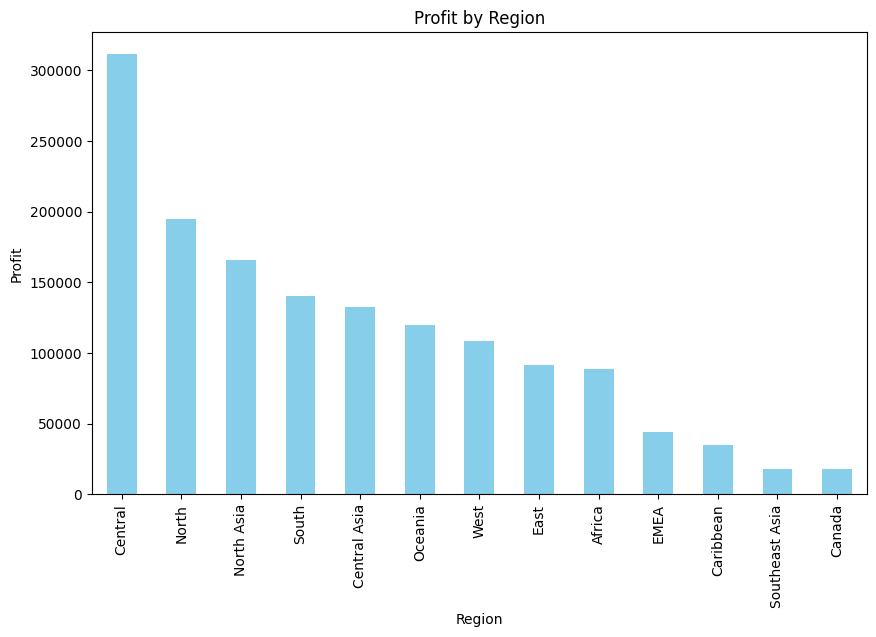

In [18]:
import matplotlib.pyplot as plt

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
region_profit.plot(kind='bar', color='skyblue')
plt.title('Profit by Region')
plt.ylabel('Profit')
plt.show()

## Sales vs Profit

“Although some regions achieve high sales, this does not always translate into high profit, suggesting that factors like discounting and product mix significantly impact profitability.”

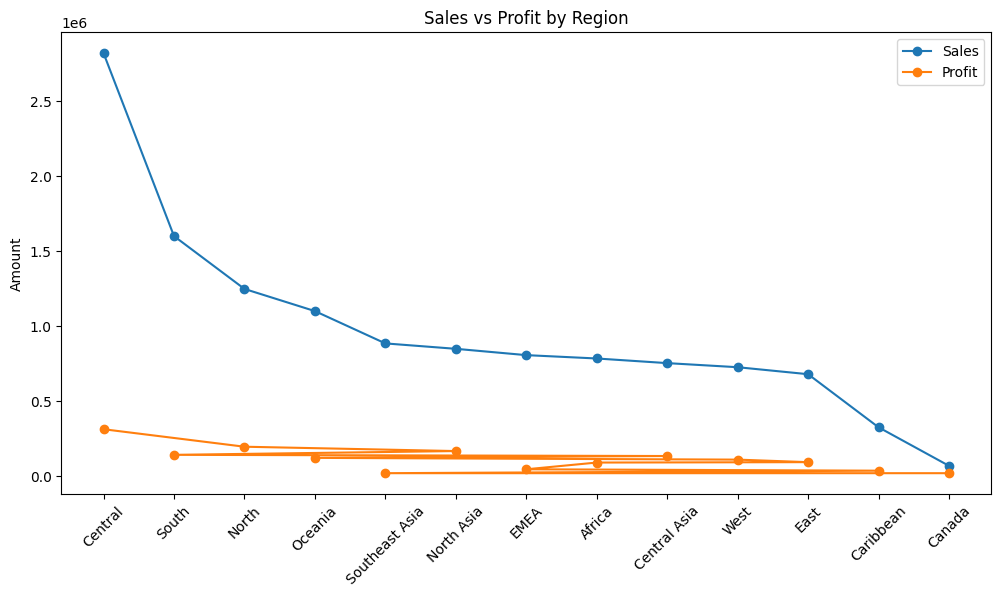

In [19]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.plot(region_sales.index, region_sales.values, marker='o', label='Sales')
plt.plot(region_profit.index, region_profit.values, marker='o', label='Profit')
plt.xticks(rotation=45)
plt.ylabel('Amount')
plt.title('Sales vs Profit by Region')
plt.legend()
plt.show()

## Top Products by Profit

“A small number of high-performing products, particularly in the Technology category, contribute disproportionately to total profit, highlighting key revenue drivers.”

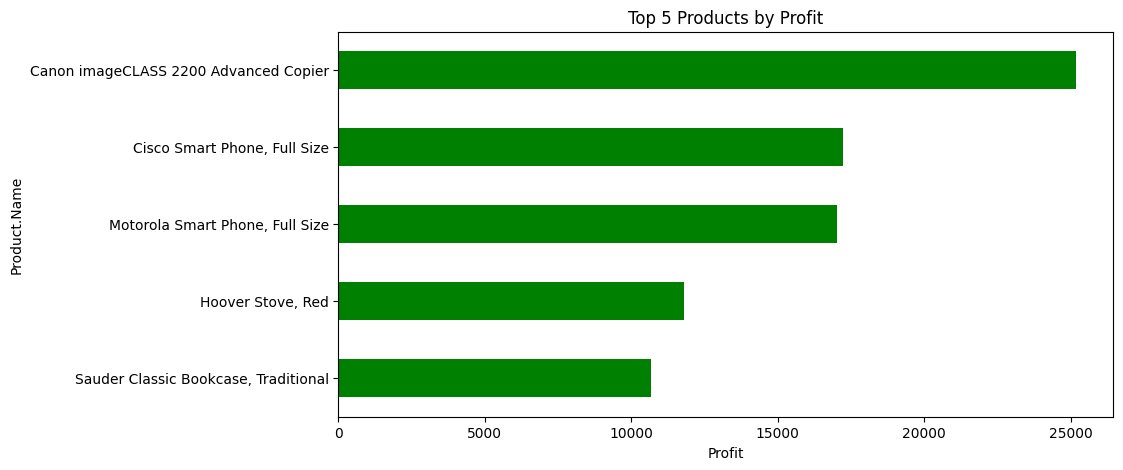

In [20]:
top5_products = df.groupby('Product.Name')['Profit'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10,5))
top5_products.plot(kind='barh', color='green')
plt.xlabel('Profit')
plt.title('Top 5 Products by Profit')
plt.gca().invert_yaxis()
plt.show()

## Discount Impact

“Profitability declines sharply as discounts increase beyond 20%, demonstrating that aggressive discounting negatively impacts margins.”

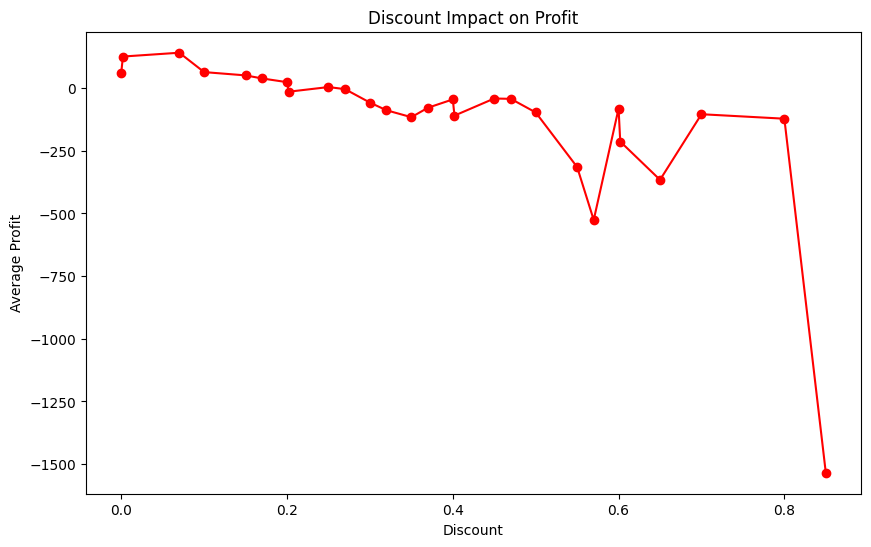

In [21]:
discount_profit = df.groupby('Discount')['Profit'].mean()

plt.figure(figsize=(10,6))
discount_profit.plot(kind='line', marker='o', color='red')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.title('Discount Impact on Profit')
plt.show()

## Business Questions

- Which region generates the highest sales and profit?
- Does higher sales always lead to higher profit?
- Which products contribute most to profitability?
- How do discounts affect profit?

## Key Insights

- Central region generates the highest profit overall.
- Sales and profit are not directly proportional across regions.
- Technology products are the most profitable category.
- Discounts above 20% significantly reduce profitability.

## Conclusion

The analysis shows that while some regions generate high sales, profitability depends heavily on product mix and discount strategy. Technology products drive the most profit, and excessive discounting negatively impacts margins. Businesses should focus on high-margin products and controlled discount strategies to maximize profitability.

## ADVANCED analysis 

# Profit margin analysis

The analysis shows that while some regions generate high sales, profitability depends heavily on product mix and discount strategy. Technology products drive the most profit, and excessive discounting negatively impacts margins. Businesses should focus on high-margin products and controlled discount strategies to maximize profitability.

In [24]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

In [23]:
df.groupby('Category')['Profit_Margin'].mean()

Category
Furniture          0.008705
Office Supplies        -inf
Technology         0.049658
Name: Profit_Margin, dtype: float64